In [1]:
import os 

#Choose GPU
os.environ["CUDA_VISIBLE_DEVICES"]="0"

#Choose CPUq
my_cores={0,1,2}
os.sched_setaffinity(0,my_cores)
num_threads = str(len(my_cores))


#Force math libraries in the chosen number of heads
os.environ["OMP_NUM_THREADS"] = num_threads
os.environ["OPENBLAS_NUM_THREADS"] = num_threads
os.environ["MKL_NUM_THREADS"] = num_threads
os.environ["VECLIB_MAXIMUM_THREADS"] = num_threads
os.environ["NUMEXPR_NUM_THREADS"] = num_threads


os.environ["XLA_FLAGS"] = f"--intra_op_parallelism_threads={num_threads} --inter_op_parallelism_threads={num_threads}"
os.environ["TF_NUM_INTRAOP_THREADS"] = num_threads
os.environ["TF_NUM_INTEROP_THREADS"] = num_threads

# 5. Force PyTorch to obey the limits
import torch # Must import AFTER os.environ but BEFORE the rest of your code
torch.set_num_threads(len(my_cores))
torch.set_num_interop_threads(len(my_cores))

# Now it is safe to import everything else!
import numpy as np

print(f"Hardware locked! Pinned strictly to CPUs: {os.sched_getaffinity(0)}")

import numpy as np



Hardware locked! Pinned strictly to CPUs: {0, 1, 2}


In [2]:
# 1. Download the nanoGPT code
!git clone https://github.com/karpathy/nanoGPT.git

# 2. Download Shakespeare and convert the characters into integer tokens
!cd nanoGPT && python data/shakespeare_char/prepare.py

fatal: destination path 'nanoGPT' already exists and is not an empty directory.


length of dataset in characters: 1,115,394
all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65
train has 1,003,854 tokens
val has 111,540 tokens


In [3]:
import sys
import torch

# Tell Python where to find Karpathy's code
sys.path.append('nanoGPT')
from model import GPTConfig, GPT

# 1. Find the brain we just trained
checkpoint_path = 'nanoGPT/out-shakespeare-char/ckpt.pt'
checkpoint = torch.load(checkpoint_path, map_location='cuda')

# 2. Rebuild the model's architecture
gptconf = GPTConfig(**checkpoint['model_args'])
model = GPT(gptconf)

# ========================================================
# THE FIX: Clean the PyTorch 2.0 compiled prefixes
# ========================================================
state_dict = checkpoint['model']
unwanted_prefix = '_orig_mod.'

for k, v in list(state_dict.items()):
    if k.startswith(unwanted_prefix):
        # Create a new key without the prefix, and delete the old one
        state_dict[k[len(unwanted_prefix):]] = state_dict.pop(k)
# ========================================================

# 3. Load the cleaned knowledge into the model
model.load_state_dict(state_dict)
model.to('cuda') # Move it to your dedicated GPU
model.eval()     # Put the model in "prediction" mode

print(f"Success! Your nanoGPT has {model.get_num_params()/1e6:.2f} million parameters.")

number of parameters: 10.65M
Success! Your nanoGPT has 10.65 million parameters.


Initializing Model for Streaming Batch Experiment...
number of parameters: 10.67M

--- Starting AdamW Streaming Run (Target LR=0.005) ---


/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Iter 000 | LR: 0.000100 | Loss: 4.1711 | H: 261.8 | Prec_H: 261.8 | FD: 34.4
Iter 010 | LR: 0.001100 | Loss: 3.3018 | H: 37.4 | Prec_H: 7638.6 | FD: 1.4
Iter 020 | LR: 0.002100 | Loss: 3.3032 | H: 43.7 | Prec_H: 4913.5 | FD: 0.7
Iter 030 | LR: 0.003100 | Loss: 3.3723 | H: 51.1 | Prec_H: 3144.6 | FD: 0.6
Iter 040 | LR: 0.004100 | Loss: 3.2917 | H: 45.1 | Prec_H: 6140.6 | FD: 1.1
Iter 050 | LR: 0.005000 | Loss: 3.3910 | H: 395892.4 | Prec_H: 794465472.0 | FD: 6.8
Iter 060 | LR: 0.005000 | Loss: 3.3325 | H: 302.4 | Prec_H: 822724.6 | FD: 1.2
Iter 070 | LR: 0.005000 | Loss: 3.2553 | H: 397.9 | Prec_H: 535673.8 | FD: 0.7
Iter 080 | LR: 0.005000 | Loss: 3.1735 | H: 49.8 | Prec_H: 44344.2 | FD: 1.0
Iter 090 | LR: 0.005000 | Loss: 3.1578 | H: 181.6 | Prec_H: 168062.8 | FD: 0.5
Iter 100 | LR: 0.005000 | Loss: 3.1247 | H: 269.9 | Prec_H: 272503.1 | FD: 0.5
Iter 110 | LR: 0.005000 | Loss: 3.1582 | H: 7139.8 | Prec_H: 6957049.5 | FD: 0.9
Iter 120 | LR: 0.005000 | Loss: 3.0428 | H: 370.7 | Prec_H: 

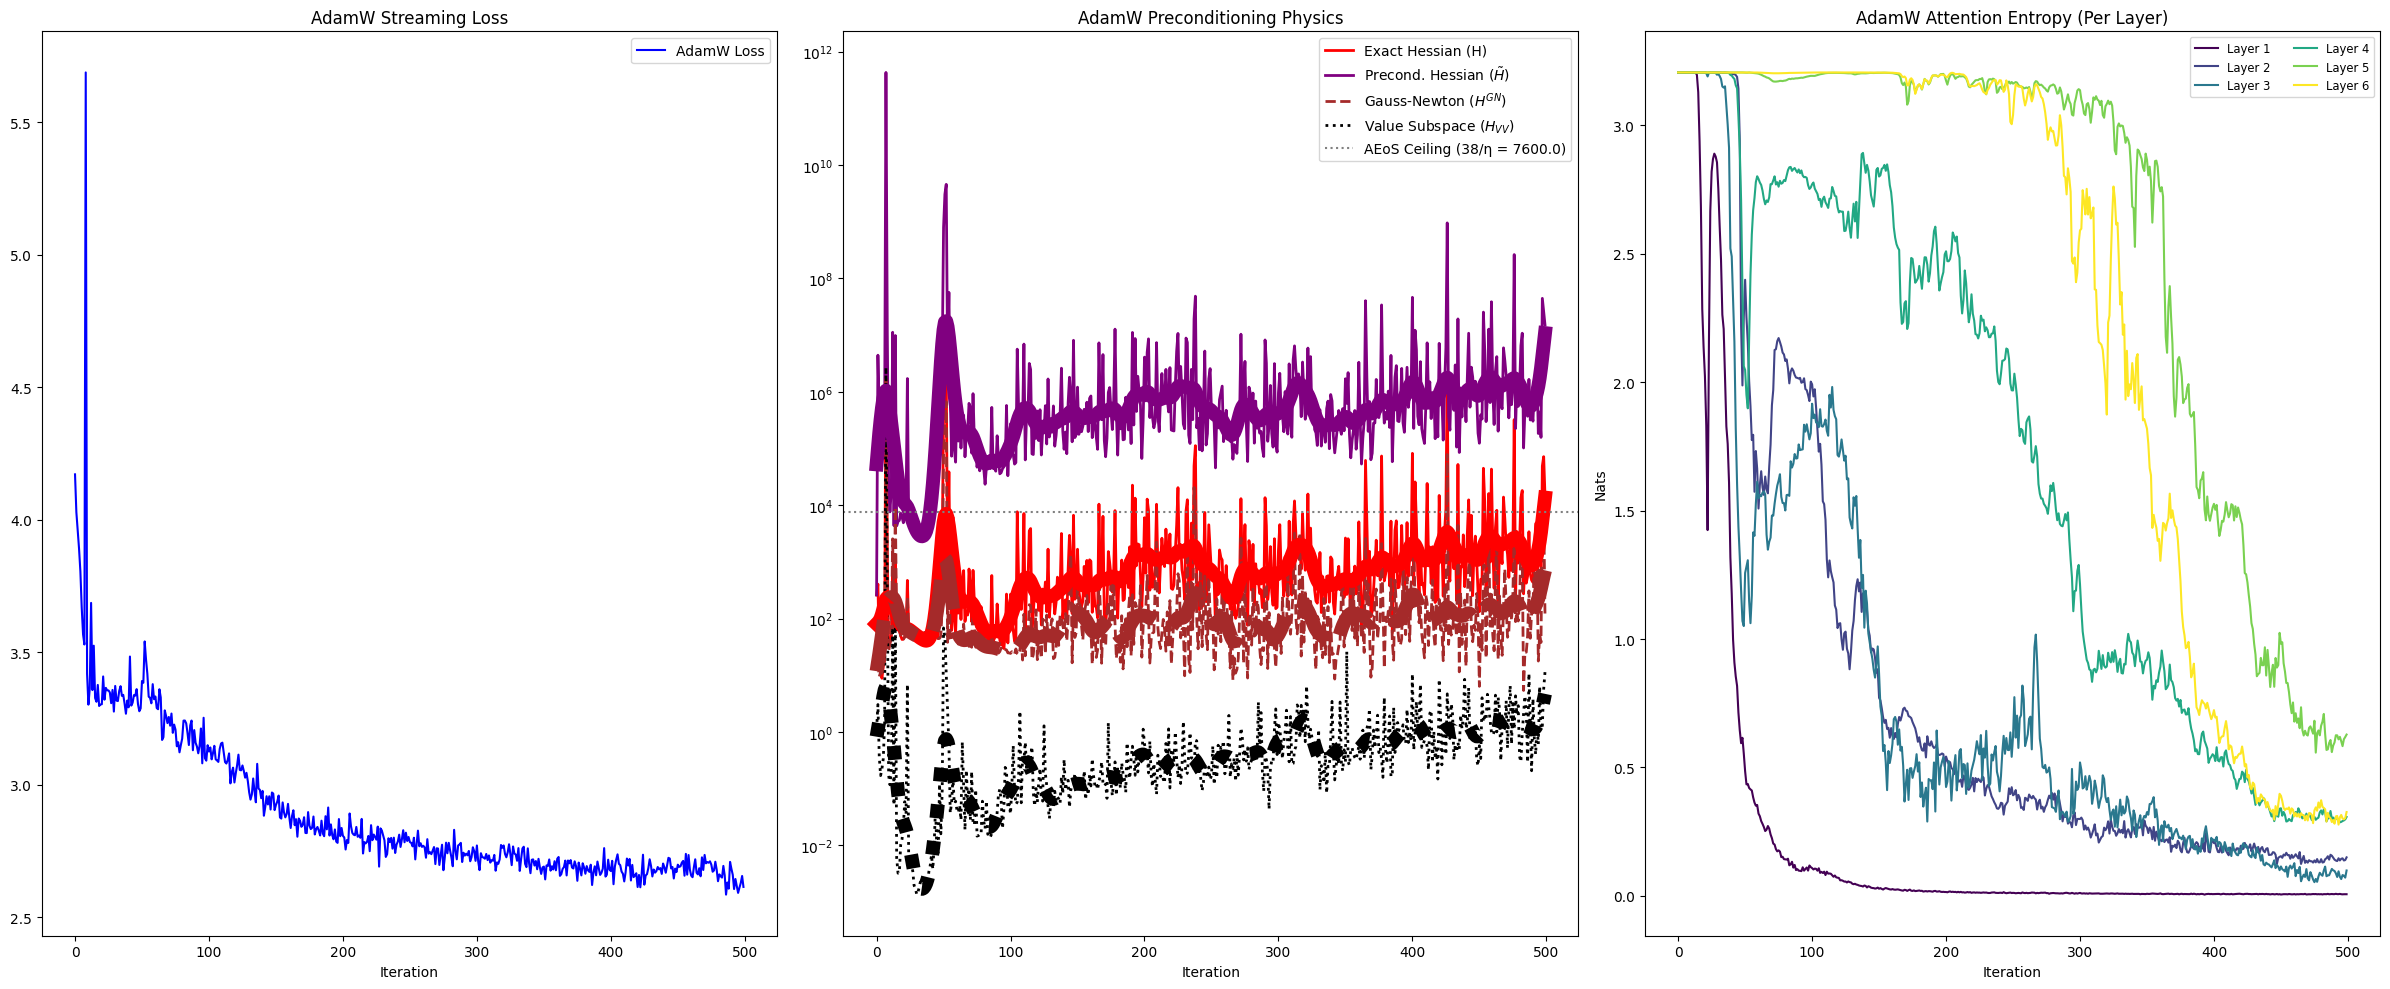

In [4]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import sys
import scipy.stats as stats
from torch.func import functional_call, jvp, vjp
import types

# =======================================================
# 0. DATA LOADING & BATCHING
# =======================================================
data_path = 'nanoGPT/data/shakespeare_char/train.bin'

if os.path.exists(data_path):
    train_data = np.memmap(data_path, dtype=np.uint16, mode='r')
else:
    print(f"Warning: {data_path} not found. Using random synthetic data to run.")
    train_data = np.random.randint(0, 65, size=(100000,), dtype=np.uint16)

def get_batch(batch_size=256, block_size=64):
    ix = torch.randint(len(train_data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((train_data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((train_data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to('cuda'), y.to('cuda')

# =======================================================
# 1. EXPERIMENT SETUP (STREAMING MODEL)
# =======================================================
REPO_PATH = os.path.join(os.getcwd(), 'nanoGPT')
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)
from model import GPT, GPTConfig

class HookedGPT(GPT):
    def __init__(self, config):
        super().__init__(config)
        self.config.flash = False
        self.apply(self._init_weights)
        
        # Override weights for stability experimentation
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.002 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.002)
            if module.bias is not None: torch.nn.init.zeros_(module.bias)
        elif isinstance(module, torch.nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.002)

    def forward(self, idx, targets=None):
        return super().forward(idx, targets)

# --- ENTROPY CALCULATION (PER LAYER) ---
def get_attention_entropy(model):
    """
    Computes Shannon entropy of the attention matrices.
    Returns a list of mean entropies, one for each layer.
    """
    layer_entropies = []
    
    for block in model.transformer.h:
        if hasattr(block.attn, 'last_att'):
            att = block.attn.last_att # Shape: (B, nh, T, T)
            # Shannon entropy: -sum(p * log(p)) over the last dimension (T)
            entropy = -torch.sum(att * torch.log(att + 1e-9), dim=-1) # (B, nh, T)
            # Average over Batch, Heads, and Sequence Length for this specific layer
            layer_entropies.append(entropy.mean().item())
        else:
            layer_entropies.append(0.0)
            
    return layer_entropies

print("Initializing Model for Streaming Batch Experiment...")
config = GPTConfig(block_size=64, vocab_size=65, n_layer=6, n_head=6, n_embd=384)
model = HookedGPT(config).to('cuda')

# --- MONKEY PATCH FORWARD PASS TO CATCH ATTENTION ---
def patched_attn_forward(self, x):
    B, T, C = x.size()
    q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) 
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) 
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) 

    att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
    att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
    att = F.softmax(att, dim=-1)
    
    # Cache the computed attention matrix for entropy calculations
    self.last_att = att.detach()
    
    att = self.attn_dropout(att)
    y = att @ v 
    y = y.transpose(1, 2).contiguous().view(B, T, C)
    y = self.resid_dropout(self.c_proj(y))
    return y

for block in model.transformer.h:
    block.attn.flash = False 
    mask = torch.tril(torch.ones(config.block_size, config.block_size))
    mask = mask.view(1, 1, config.block_size, config.block_size).to('cuda')
    block.attn.register_buffer("bias", mask)
    # Bind the patched forward pass to each attention module
    block.attn.forward = types.MethodType(patched_attn_forward, block.attn)

initial_weights = {k: v.clone() for k, v in model.state_dict().items()}

# =======================================================
# 2. CURVATURE MATH & MASKS
# =======================================================
def get_VV_subspace_mask(model):
    mask_list = []
    for name, p in model.named_parameters():
        if 'c_attn.weight' in name:
            m = torch.zeros_like(p)
            d = p.size(0) // 3
            m[2*d:, :] = 1.0 
            mask_list.append(m.view(-1))
        elif 'c_attn.bias' in name:
            m = torch.zeros_like(p)
            d = p.size(0) // 3
            m[2*d:] = 1.0
            mask_list.append(m.view(-1))
        else:
            mask_list.append(torch.zeros_like(p).view(-1))
    return torch.cat(mask_list)

vv_mask_global = get_VV_subspace_mask(model).to('cuda')

def get_curvature_metrics(model, optimizer, X, Y, loss, vv_mask, max_iter=10):
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True, retain_graph=True)
    flat_grads = torch.cat([g.view(-1) for g in grads])
    
    # --- 1. Exact Hessian Power Iteration (H) ---
    v_h = torch.randn_like(flat_grads)
    v_h = v_h / (torch.norm(v_h) + 1e-9)
    for _ in range(max_iter):
        hvp = torch.autograd.grad(flat_grads, model.parameters(), grad_outputs=v_h, retain_graph=True)
        flat_hvp = torch.cat([g.contiguous().view(-1) for g in hvp])
        v_h = flat_hvp / (torch.norm(flat_hvp) + 1e-9)
    hessian_norm = torch.dot(v_h, flat_hvp).item()
    
    # --- 2. Value Subspace Power Iteration (H_VV) ---
    v_vv = torch.randn_like(flat_grads) * vv_mask
    v_vv = v_vv / (torch.norm(v_vv) + 1e-9)
    for _ in range(max_iter):
        hvp_vv = torch.autograd.grad(flat_grads, model.parameters(), grad_outputs=v_vv, retain_graph=True)
        flat_hvp_vv = torch.cat([g.contiguous().view(-1) for g in hvp_vv])
        v_vv = (flat_hvp_vv * vv_mask) 
        v_vv = v_vv / (torch.norm(v_vv) + 1e-9)
    hessian_vv_norm = torch.dot(v_vv, flat_hvp_vv).item()
    
    # --- 3. Preconditioned Hessian Power Iteration (H_tilde) ---
    D_inv_sqrt = []
    is_adam = False
    
    for p in model.parameters():
        state = optimizer.state.get(p, {})
        if 'exp_avg_sq' in state and state['exp_avg_sq'].numel() > 0:
            is_adam = True
            v = state['exp_avg_sq']
            step = state.get('step', 1)
            if isinstance(step, torch.Tensor): step = step.item()
                
            beta2 = optimizer.param_groups[0]['betas'][1]
            
            bias_correction2 = 1 - beta2 ** step
            v_hat = v / bias_correction2
            eps_paper = 1e-7 
            
            P_matrix = torch.sqrt(v_hat) + eps_paper
            d_inv_sqrt = 1.0 / torch.sqrt(P_matrix)
            
            D_inv_sqrt.append(d_inv_sqrt.view(-1))
        else:
            D_inv_sqrt.append(torch.ones_like(p).view(-1))
            
    D_inv_sqrt = torch.cat(D_inv_sqrt)
    
    if is_adam:
        v_prec = torch.randn_like(flat_grads)
        v_prec = v_prec / (torch.norm(v_prec) + 1e-9)
        
        for _ in range(max_iter):
            step1 = D_inv_sqrt * v_prec
            hvp_prec = torch.autograd.grad(flat_grads, model.parameters(), grad_outputs=step1, retain_graph=True)
            flat_hvp_prec = torch.cat([g.contiguous().view(-1) for g in hvp_prec])
            step3 = D_inv_sqrt * flat_hvp_prec
            v_prec = step3 / (torch.norm(step3) + 1e-9)
            
        prec_hessian_norm = torch.dot(v_prec, step3).item()
    else:
        prec_hessian_norm = hessian_norm

    del grads, flat_grads, v_h, flat_hvp, D_inv_sqrt, hvp_vv, flat_hvp_vv, v_vv
    if is_adam: del v_prec, step1, hvp_prec, flat_hvp_prec, step3
    torch.cuda.empty_cache()
    
    # --- 4. Gauss-Newton (H_GN) ---
    params = dict(model.named_parameters())
    def fwd(p_dict):
        logt, _ = functional_call(model, p_dict, (X, Y))
        return logt

    flat_params = torch.cat([p.view(-1) for p in model.parameters()])
    v_g = torch.randn_like(flat_params)
    v_g = v_g / torch.norm(v_g)
    
    for _ in range(max_iter):
        tangents = {}
        offset = 0
        for k, p in params.items():
            numel = p.numel()
            tangents[k] = v_g[offset:offset+numel].view_as(p)
            offset += numel
        
        out_logits, Jv = jvp(fwd, (params,), (tangents,))
        if not out_logits.requires_grad: out_logits.requires_grad_(True)
            
        vocab_size = out_logits.size(-1)
        l = F.cross_entropy(out_logits.view(-1, vocab_size), Y.view(-1))
        
        grad_l = torch.autograd.grad(l, out_logits, create_graph=True)[0]
        H_L_Jv = torch.autograd.grad(grad_l, out_logits, grad_outputs=Jv)[0] 
        
        _, vjp_fn = vjp(fwd, params)
        GN_v_dict = vjp_fn(H_L_Jv.detach())[0] 
        
        flat_GN_v = torch.cat([GN_v_dict[k].contiguous().view(-1) for k in params.keys()])
        v_g = flat_GN_v / (torch.norm(flat_GN_v) + 1e-9)
        
        del out_logits, Jv, l, grad_l, H_L_Jv, GN_v_dict, tangents
        
    gn_norm = torch.dot(v_g, flat_GN_v).item()
    torch.cuda.empty_cache()
    
    return hessian_norm, prec_hessian_norm, hessian_vv_norm, gn_norm

def second_difference_matrix(n: int):
    """
    D is the (n-2) x n matrix such that (Dm)_i = m_i - 2 m_{i+1} + m_{i+2}.
    """
    if n < 3:
        return np.zeros((0, n), dtype=np.float64)
    D = np.zeros((n - 2, n), dtype=np.float64)
    for i in range(n - 2):
        D[i, i:i+3] = [1.0, -2.0, 1.0]
    return D


def smooth_log_trend(y, lam=100.0, eps=1e-12, use_abs=False):
    """
    Smooth a positive series y by solving:
        min_m ||log(y+eps) - m||^2 + lam ||D m||^2

    Returns:
        trend_raw: exp(m), smooth trend on original scale
        trend_log: m, smooth trend on log scale
        log_y: raw log-series
    """
    y = np.asarray(y, dtype=np.float64)

    # If your "sharpness" estimator is conceptually nonnegative but may
    # occasionally come out negative due to numerical noise, set use_abs=True.
    if use_abs:
        y_safe = np.abs(y) + eps
    else:
        y_safe = np.maximum(y, eps)

    log_y = np.log(y_safe)
    n = len(log_y)

    if n < 3:
        return y_safe.copy(), log_y.copy(), log_y.copy()

    D = second_difference_matrix(n)
    A = np.eye(n, dtype=np.float64) + lam * (D.T @ D)

    trend_log = np.linalg.solve(A, log_y)
    trend_raw = np.exp(trend_log)

    return trend_raw, trend_log, log_y


# =======================================================
# 3. UPDATED TRAINING LOOP (H, Prec_H, FD, GN, VV, Entropy)
# =======================================================
def run_streaming_experiment(optimizer_name, target_lr, iterations=400):
    model.load_state_dict({k: v.clone() for k, v in initial_weights.items()})
    
    if optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=target_lr, eps=1e-5)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=target_lr)
        
    history = {'loss': [], 'hessian': [], 'prec_h': [], 'fd': [], 'vv': [], 'gn': [], 'entropy': []}
    
    warmup_iters = max(1, int(0.1 * iterations))
    decay_iters = max(1, int(0.1 * iterations))
    decay_start = iterations - decay_iters
    min_lr = target_lr * 0.1 
    
    last_h, last_prec_h, last_fd, last_vv, last_gn = 0.0, 0.0, 0.0, 0.0, 0.0
    
    print(f"\n--- Starting {optimizer_name} Streaming Run (Target LR={target_lr}) ---")
    
    for i in range(iterations):
        # LR Scheduler
        if i < warmup_iters:
            current_lr = target_lr * (i + 1) / warmup_iters
        elif i < decay_start:
            current_lr = target_lr
        else:
            decay_ratio = (i - decay_start) / decay_iters
            coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
            current_lr = min_lr + coeff * (target_lr - min_lr)
            
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
            
        X, Y = get_batch(batch_size=32, block_size=config.block_size)
        
        # --- COMPUTE CURVATURE EVERY 1 STEP ---
        if i % 1 == 0:
            # 1. Hessian, Preconditioned Hessian, GN, VV
            optimizer.zero_grad()
            logits, loss = model(X, Y)
            with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_mem_efficient=False, enable_math=True):
                last_h, last_prec_h, last_vv, last_gn = get_curvature_metrics(model, optimizer, X, Y, loss, vv_mask_global)
                
            # 2. Finite Difference Computation
            optimizer.zero_grad()
            logits, loss = model(X, Y)
            loss.backward()
            
            w_k = torch.cat([p.data.view(-1) for p in model.parameters()])
            g_k = torch.cat([p.grad.view(-1) for p in model.parameters()])
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            w_k1 = torch.cat([p.data.view(-1) for p in model.parameters()])
            
            optimizer.zero_grad()
            _, loss_next = model(X, Y)
            loss_next.backward()
            g_k1 = torch.cat([p.grad.view(-1) for p in model.parameters()])
            
            dw = w_k1 - w_k
            dg = g_k1 - g_k
            last_fd = (torch.norm(dg) / (torch.norm(dw) + 1e-9)).item()
            
            optimizer.zero_grad() 
            loss_val = loss.item()
            
        else:
            # Normal Step
            logits, loss = model(X, Y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_val = loss.item()
            
        # Logging
        history['loss'].append(loss_val)
        history['hessian'].append(last_h)
        history['prec_h'].append(last_prec_h)
        history['fd'].append(last_fd)
        history['vv'].append(last_vv)
        history['gn'].append(last_gn)
        
        # --- Capture Layer-wise Entropies ---
        current_entropies = get_attention_entropy(model)
        history['entropy'].append(current_entropies)
        
        if i % 10 == 0:
            print(f"Iter {i:03d} | LR: {current_lr:.6f} | Loss: {loss_val:.4f} | H: {last_h:.1f} | Prec_H: {last_prec_h:.1f} | FD: {last_fd:.1f}")
            
    return history

# =======================================================
# 4. EXECUTION & UNIFIED PLOTTING (2x4 GRID)
# =======================================================
iters = 500
lr_sgd = 1 
target_adam_lr = 0.5*1e-2 

adam_history = run_streaming_experiment('AdamW', target_adam_lr, iterations=iters)
# Global smoothing
smooth_h, smooth_h_log, log_h = smooth_log_trend(adam_history['hessian'], lam=100)
smooth_prec, smooth_prec_log, log_prec = smooth_log_trend(adam_history['prec_h'], lam=100)
smooth_gn, smooth_gn_log, log_gn = smooth_log_trend(adam_history['gn'], lam=100)
smooth_vv, smooth_vv_log, log_vv = smooth_log_trend(adam_history['vv'], lam=100)
#sgd_history = run_streaming_experiment('SGD', lr_sgd, iterations=iters)

def plot_combined_results(adam_history, target_adam_lr):
    fig, axs = plt.subplots(1, 3, figsize=(24, 10))
    
    # Convert entropy lists to numpy arrays for easier plotting by layer
    # Shape of these arrays will be (iterations, num_layers)
    adam_entropies = np.array(adam_history['entropy'])
    #sgd_entropies = np.array(sgd_history['entropy'])
    
    num_layers = adam_entropies.shape[1] if adam_entropies.ndim > 1 else 0

    # ================= ROW 0: AdamW =================
    axs[0].plot(adam_history['loss'], color='blue', label='AdamW Loss')
    axs[0].set_title("AdamW Streaming Loss")
    axs[0].set_xlabel("Iteration")
    axs[0].legend()
    
    axs[1].plot(adam_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    axs[1].plot(adam_history['prec_h'], color='purple', linestyle='-', linewidth=2, label='Precond. Hessian ($\\tilde{H}$)')
    axs[1].plot(adam_history['gn'], color='brown', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    axs[1].plot(adam_history['vv'], color='black', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    axs[1].plot(smooth_h, color='red', linewidth=10)
    axs[1].plot(smooth_prec, color='purple', linestyle='-', linewidth=10)
    axs[1].plot(smooth_gn, color='brown', linestyle='--', linewidth=10)
    axs[1].plot(smooth_vv, color='black', linestyle=':', linewidth=10)
    axs[1].axhline(y=38.0/target_adam_lr, color='gray', linestyle=':', label=f'AEoS Ceiling (38/η = {38.0/target_adam_lr:.1f})')
    axs[1].set_yscale('log')
    axs[1].set_title("AdamW Preconditioning Physics")
    axs[1].set_xlabel("Iteration")
    axs[1].legend()

    

    #axs[0, 2].plot(adam_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    #axs[0, 2].plot(adam_history['gn'], color='brown', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    #axs[0, 2].plot(adam_history['vv'], color='magenta', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    #axs[0, 2].set_yscale('log')
    #axs[0, 2].set_title("AdamW Structural Subspaces")
    #axs[0, 2].set_xlabel("Iteration")
    #axs[0, 2].legend()

    # --- Plot individual layers for AdamW Entropy ---
    colors = plt.cm.viridis(np.linspace(0, 1, num_layers))
    for layer_idx in range(num_layers):
        axs[2].plot(adam_entropies[:, layer_idx], color=colors[layer_idx], label=f'Layer {layer_idx+1}')
    axs[2].set_title("AdamW Attention Entropy (Per Layer)")
    axs[2].set_xlabel("Iteration")
    axs[2].set_ylabel("Nats")
    axs[2].legend(fontsize='small', ncol=2)

    # ================= ROW 1: SGD =================
    #axs[1, 0].plot(sgd_history['loss'], color='orange', label='SGD Loss')
    #axs[1, 0].set_title("SGD Streaming Loss")
    #axs[1, 0].set_xlabel("Iteration")
    #axs[1, 0].legend()
    
    #axs[1, 1].plot(sgd_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    #axs[1, 1].plot(sgd_history['gn'], color='purple', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    #axs[1, 1].plot(sgd_history['vv'], color='black', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    #axs[1, 1].axhline(y=2.0/target_sgd_lr, color='gray', linestyle=':', label=f'EoS Ceiling (2/η = {2.0/target_sgd_lr:.1f})')
    #axs[1, 1].set_yscale('log')
    #axs[1, 1].set_title("SGD Dynamics (No Preconditioning)")
    #axs[1, 1].set_xlabel("Iteration")
    #axs[1, 1].legend()

    #axs[1, 2].plot(sgd_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    #axs[1, 2].plot(sgd_history['gn'], color='brown', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    #axs[1, 2].plot(sgd_history['vv'], color='magenta', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    #axs[1, 2].set_yscale('log')
    #axs[1, 2].set_title("SGD Structural Subspaces")
    #axs[1, 2].set_xlabel("Iteration")
    #axs[1, 2].legend()

    # --- Plot individual layers for SGD Entropy ---
    #for layer_idx in range(num_layers):
    #    axs[1, 2].plot(sgd_entropies[:, layer_idx], color=colors[layer_idx], label=f'Layer {layer_idx+1}')
    #axs[1, 2].set_title("SGD Attention Entropy (Per Layer)")
    #axs[1, 2].set_xlabel("Iteration")
    #axs[1, 2].set_ylabel("Nats")
    #axs[1, 2].legend(fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()


plot_combined_results(adam_history, target_adam_lr)





In [6]:
# =======================================================
# 5. CORRELATION ANALYSIS
# =======================================================
def print_correlations(history, name):
    # Slice [::5] to analyze only the independently computed steps
    s=0
    h = history['hessian']
    prec_h = history['prec_h']
    fd = history['fd']
    gn = history['gn']
    vv = history['vv']
    entropy = history['entropy']
    entropy_first_layer = [sublist[0] for sublist in entropy]
    average_entropy = [sum(sublist) / len(sublist) for sublist in entropy]

    smooth_h, smooth_h_log, log_h = smooth_log_trend(adam_history['hessian'], lam=100)
    smooth_prec, smooth_prec_log, log_prec = smooth_log_trend(adam_history['prec_h'], lam=100)
    smooth_gn, smooth_gn_log, log_gn = smooth_log_trend(adam_history['gn'], lam=100)
    smooth_vv, smooth_vv_log, log_vv = smooth_log_trend(adam_history['vv'], lam=100)
    
    sp_vv_prec, _ = stats.spearmanr(vv[s:], prec_h[s:])
    pe_vv_prec, _ = stats.pearsonr(vv[s:], prec_h[s:])
    
    sp_gn_prec, _ = stats.spearmanr(gn[s:], prec_h[s:])
    pe_gn_prec, _ = stats.pearsonr(gn[s:], prec_h[s:])

    sp_vv_prec_smooth, _ = stats.spearmanr(smooth_vv[s:], smooth_prec[s:])
    pe_vv_prec_smooth, _ = stats.pearsonr(smooth_vv[s:], smooth_prec[s:])
    
    sp_gn_prec_smooth, _ = stats.spearmanr(smooth_gn[s:], smooth_prec[s:])
    pe_gn_prec_smooth, _ = stats.pearsonr(smooth_gn[s:], smooth_prec[s:])

    sp_vv_entropy, _ = stats.spearmanr(vv[s:], entropy_first_layer[s:])
    pe_vv_etnropy, _ = stats.pearsonr(vv[s:], entropy_first_layer[s:])

    sp_prec_entropy, _ = stats.spearmanr(prec_h[s:], entropy_first_layer[s:])
    pe_prec_entropy, _ = stats.pearsonr(prec_h[s:], entropy_first_layer[s:])

    sp_h_entropy, _ = stats.spearmanr(h[s:], entropy_first_layer[s:])
    pe_h_entropy, _ = stats.pearsonr(h[s:], entropy_first_layer[s:])

    sp_h_average_entropy, _ = stats.spearmanr(h[s:], average_entropy[s:])
    pe_h_average_entropy, _ = stats.pearsonr(h[s:], average_entropy[s:])

    sp_vv_entropy_smooth, _ = stats.spearmanr(smooth_vv[s:], entropy_first_layer[s:])
    pe_vv_etnropy_smooth, _ = stats.pearsonr(smooth_vv[s:], entropy_first_layer[s:])

    sp_prec_entropy_smooth, _ = stats.spearmanr(smooth_prec[s:], entropy_first_layer[s:])
    pe_prec_entropy_smooth, _ = stats.pearsonr(smooth_prec[s:], entropy_first_layer[s:])

    sp_h_entropy_smooth, _ = stats.spearmanr(smooth_h[s:], entropy_first_layer[s:])
    pe_h_entropy_smooth, _ = stats.pearsonr(smooth_h[s:], entropy_first_layer[s:])

    sp_h_average_entropy_smooth, _ = stats.spearmanr(smooth_h[s:], average_entropy[s:])
    pe_h_average_entropy_smooth, _ = stats.pearsonr(smooth_h[s:], average_entropy[s:])
    
    
    print(f"\n--- {name} Correlation Results ---")
    print(f"VV vs Prec_H  -> Spearman: {sp_vv_prec:.4f} | Pearson: {pe_vv_prec:.4f}")
    print(f"GN vs Prec_H  -> Spearman: {sp_gn_prec:.4f} | Pearson: {pe_gn_prec:.4f}")

    print(f"\n--- {name} Smoothed Correlation Results ---")
    print(f"VV vs Prec_H  -> Spearman: {sp_vv_prec_smooth:.4f} | Pearson: {pe_vv_prec_smooth:.4f}")
    print(f"GN vs Prec_H  -> Spearman: {sp_gn_prec_smooth:.4f} | Pearson: {pe_gn_prec_smooth:.4f}")

    print(f"\n--- {name} Raw Correlation Results vs Entropy ---")
    print(f"VV vs Entropy  -> Spearman: {sp_vv_entropy:.4f} | Pearson: {pe_vv_etnropy:.4f}")
    print(f"Prec_H vs Entropy  -> Spearman: {sp_prec_entropy:.4f} | Pearson: {pe_prec_entropy:.4f}")
    print(f"H vs Entropy  -> Spearman: {sp_h_entropy:.4f} | Pearson: {pe_h_entropy:.4f}")
    print(f"H vs Average Entropy  -> Spearman: {sp_h_average_entropy:.4f} | Pearson: {pe_h_average_entropy:.4f}")


    print(f"\n--- {name} Smoothed Correlation Results vs Entropy ---")
    print(f"VV vs Entropy  -> Spearman: {sp_vv_entropy_smooth:.4f} | Pearson: {pe_vv_etnropy_smooth:.4f}")
    print(f"Prec_H vs Entropy  -> Spearman: {sp_prec_entropy_smooth:.4f} | Pearson: {pe_prec_entropy_smooth:.4f}")
    print(f"H vs Entropy  -> Spearman: {sp_h_entropy_smooth:.4f} | Pearson: {pe_h_entropy_smooth:.4f}")
    print(f"H vs Average Entropy  -> Spearman: {sp_h_average_entropy_smooth:.4f} | Pearson: {pe_h_average_entropy_smooth:.4f}")






print_correlations(adam_history, "AdamW")


--- AdamW Correlation Results ---
VV vs Prec_H  -> Spearman: 0.4914 | Pearson: 0.9999
GN vs Prec_H  -> Spearman: 0.6000 | Pearson: 0.9173

--- AdamW Smoothed Correlation Results ---
VV vs Prec_H  -> Spearman: 0.7217 | Pearson: 0.2621
GN vs Prec_H  -> Spearman: 0.7726 | Pearson: 0.9253

--- AdamW Raw Correlation Results vs Entropy ---
VV vs Entropy  -> Spearman: -0.6605 | Pearson: 0.1786
Prec_H vs Entropy  -> Spearman: -0.3762 | Pearson: 0.1787
H vs Entropy  -> Spearman: -0.4772 | Pearson: 0.1659
H vs Average Entropy  -> Spearman: -0.5092 | Pearson: 0.0869

--- AdamW Smoothed Correlation Results vs Entropy ---
VV vs Entropy  -> Spearman: -0.7599 | Pearson: 0.2082
Prec_H vs Entropy  -> Spearman: -0.5735 | Pearson: -0.0637
H vs Entropy  -> Spearman: -0.6919 | Pearson: -0.2230
H vs Average Entropy  -> Spearman: -0.7326 | Pearson: -0.4665


Initializing Model for Streaming Batch Experiment...
number of parameters: 10.67M

--- Starting AdamW Streaming Run (Target LR=0.0001) ---
Iter 000 | LR: 0.000002 | T: 1.000 | Loss: 4.1720 | H: 254.6 | Prec_H: 254.6 | FD: 63.2
Iter 010 | LR: 0.000022 | T: 1.000 | Loss: 3.9966 | H: 89.2 | Prec_H: 981786.1 | FD: 10.0
Iter 020 | LR: 0.000042 | T: 1.000 | Loss: 3.8950 | H: 22.2 | Prec_H: 320486.4 | FD: 4.8
Iter 030 | LR: 0.000062 | T: 1.000 | Loss: 3.7277 | H: 18.4 | Prec_H: 236550.5 | FD: 3.9
Iter 040 | LR: 0.000082 | T: 1.000 | Loss: 3.5830 | H: 863.2 | Prec_H: 2874501.0 | FD: 25.0
Iter 050 | LR: 0.000100 | T: 1.000 | Loss: 3.3604 | H: 822.3 | Prec_H: 1209203.0 | FD: 32.6
Iter 060 | LR: 0.000100 | T: 1.000 | Loss: 3.1999 | H: 596.6 | Prec_H: 901356.8 | FD: 44.7
Iter 070 | LR: 0.000100 | T: 1.000 | Loss: 3.1135 | H: 513.2 | Prec_H: 516940.8 | FD: 43.4
Iter 080 | LR: 0.000100 | T: 1.000 | Loss: 3.0413 | H: 564.4 | Prec_H: 458405.0 | FD: 28.8
Iter 090 | LR: 0.000100 | T: 1.000 | Loss: 2.918

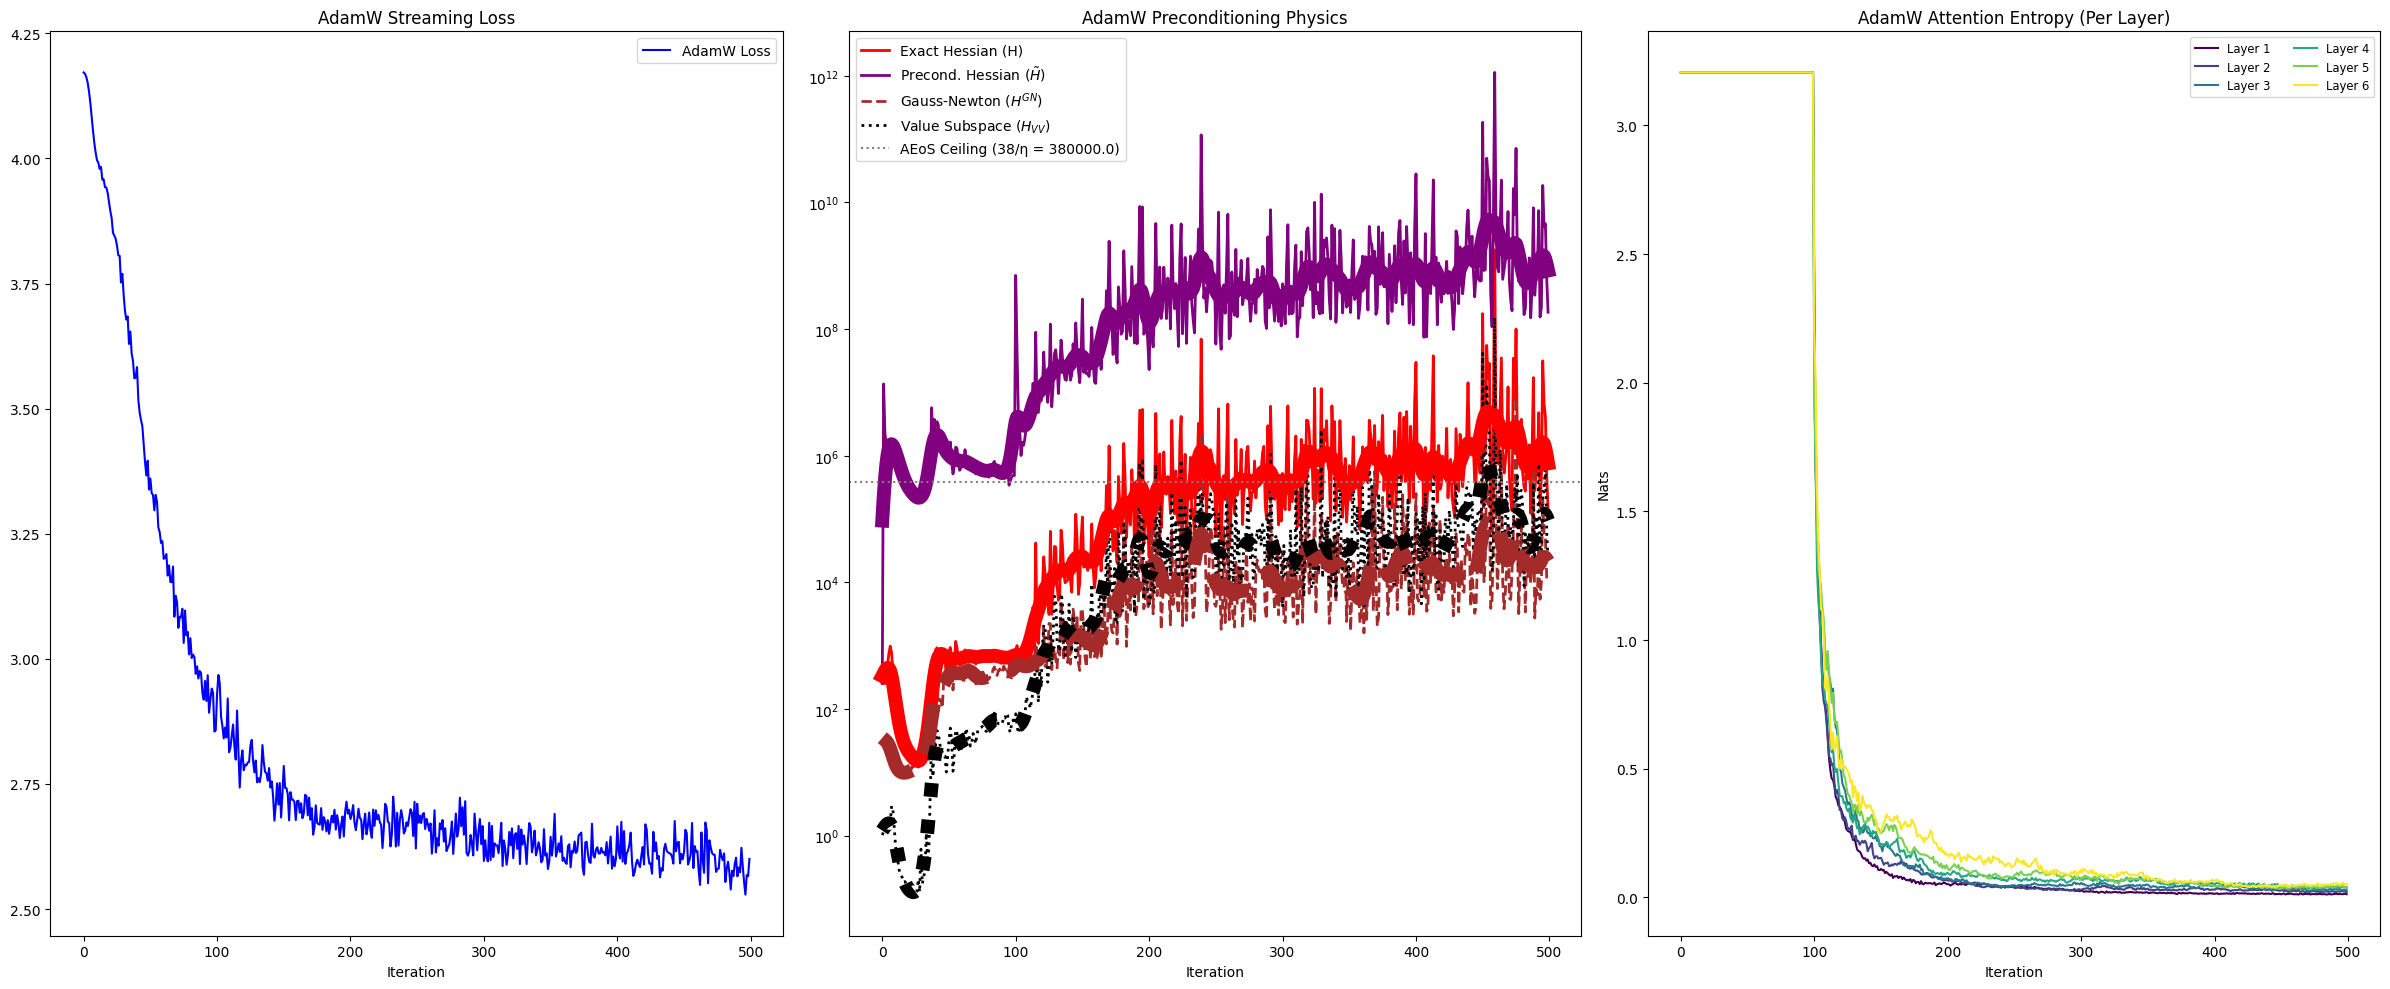

In [7]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import sys
import scipy.stats as stats
from torch.func import functional_call, jvp, vjp
import types

# =======================================================
# 0. DATA LOADING & BATCHING
# =======================================================
data_path = 'nanoGPT/data/shakespeare_char/train.bin'

if os.path.exists(data_path):
    train_data = np.memmap(data_path, dtype=np.uint16, mode='r')
else:
    print(f"Warning: {data_path} not found. Using random synthetic data to run.")
    train_data = np.random.randint(0, 65, size=(100000,), dtype=np.uint16)

def get_batch(batch_size=256, block_size=64):
    ix = torch.randint(len(train_data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((train_data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((train_data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    return x.to('cuda'), y.to('cuda')

# =======================================================
# ADD: GLOBAL ATTENTION TEMPERATURE HELPERS
# =======================================================
def set_attention_temperature(model, temperature, layers=None):
    """
    Set attention temperature for all layers, or only a subset.
    Smaller temperature => sharper attention.
    """
    temperature = float(temperature)
    if layers is None:
        layers = range(len(model.transformer.h))
    for layer_idx in layers:
        model.transformer.h[layer_idx].attn.temperature = temperature

def get_attention_temperature(model):
    return getattr(model.transformer.h[0].attn, 'temperature', 1.0)

# =======================================================
# 1. EXPERIMENT SETUP (STREAMING MODEL)
# =======================================================
REPO_PATH = os.path.join(os.getcwd(), 'nanoGPT')
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)
from model import GPT, GPTConfig

class HookedGPT(GPT):
    def __init__(self, config):
        super().__init__(config)
        self.config.flash = False
        self.apply(self._init_weights)
        
        # Override weights for stability experimentation
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.002 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.002)
            if module.bias is not None: torch.nn.init.zeros_(module.bias)
        elif isinstance(module, torch.nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.002)

    def forward(self, idx, targets=None):
        return super().forward(idx, targets)

# --- ENTROPY CALCULATION (PER LAYER) ---
def get_attention_entropy(model):
    """
    Computes Shannon entropy of the attention matrices.
    Returns a list of mean entropies, one for each layer.
    """
    layer_entropies = []
    
    for block in model.transformer.h:
        if hasattr(block.attn, 'last_att'):
            att = block.attn.last_att # Shape: (B, nh, T, T)
            # Shannon entropy: -sum(p * log(p)) over the last dimension (T)
            entropy = -torch.sum(att * torch.log(att + 1e-9), dim=-1) # (B, nh, T)
            # Average over Batch, Heads, and Sequence Length for this specific layer
            layer_entropies.append(entropy.mean().item())
        else:
            layer_entropies.append(0.0)
            
    return layer_entropies

print("Initializing Model for Streaming Batch Experiment...")
config = GPTConfig(block_size=64, vocab_size=65, n_layer=6, n_head=6, n_embd=384)
model = HookedGPT(config).to('cuda')

# --- MONKEY PATCH FORWARD PASS TO CATCH ATTENTION ---
def patched_attn_forward(self, x):
    B, T, C = x.size()
    q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
    k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) 
    q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) 
    v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) 

    # raw attention logits
    att_logits = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))

    # NEW: temperature intervention
    # smaller temperature => divide by smaller number => larger logits => lower entropy
    temp = getattr(self, 'temperature', 1.0)
    att_logits = att_logits / max(temp, 1e-8)

    att_logits = att_logits.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
    att = F.softmax(att_logits, dim=-1)
    
    # Cache the computed attention matrix for entropy calculations
    self.last_att = att.detach()
    
    att = self.attn_dropout(att)
    y = att @ v 
    y = y.transpose(1, 2).contiguous().view(B, T, C)
    y = self.resid_dropout(self.c_proj(y))
    return y

for block in model.transformer.h:
    block.attn.flash = False 
    mask = torch.tril(torch.ones(config.block_size, config.block_size))
    mask = mask.view(1, 1, config.block_size, config.block_size).to('cuda')
    block.attn.register_buffer("bias", mask)
    # NEW: default temperature
    block.attn.temperature = 1.0

    block.attn.forward = types.MethodType(patched_attn_forward, block.attn)

initial_weights = {k: v.clone() for k, v in model.state_dict().items()}

# =======================================================
# 2. CURVATURE MATH & MASKS
# =======================================================
def get_VV_subspace_mask(model):
    mask_list = []
    for name, p in model.named_parameters():
        if 'c_attn.weight' in name:
            m = torch.zeros_like(p)
            d = p.size(0) // 3
            m[2*d:, :] = 1.0 
            mask_list.append(m.view(-1))
        elif 'c_attn.bias' in name:
            m = torch.zeros_like(p)
            d = p.size(0) // 3
            m[2*d:] = 1.0
            mask_list.append(m.view(-1))
        else:
            mask_list.append(torch.zeros_like(p).view(-1))
    return torch.cat(mask_list)

vv_mask_global = get_VV_subspace_mask(model).to('cuda')

def get_curvature_metrics(model, optimizer, X, Y, loss, vv_mask, max_iter=10):
    grads = torch.autograd.grad(loss, model.parameters(), create_graph=True, retain_graph=True)
    flat_grads = torch.cat([g.view(-1) for g in grads])
    
    # --- 1. Exact Hessian Power Iteration (H) ---
    v_h = torch.randn_like(flat_grads)
    v_h = v_h / (torch.norm(v_h) + 1e-9)
    for _ in range(max_iter):
        hvp = torch.autograd.grad(flat_grads, model.parameters(), grad_outputs=v_h, retain_graph=True)
        flat_hvp = torch.cat([g.contiguous().view(-1) for g in hvp])
        v_h = flat_hvp / (torch.norm(flat_hvp) + 1e-9)
    hessian_norm = torch.dot(v_h, flat_hvp).item()
    
    # --- 2. Value Subspace Power Iteration (H_VV) ---
    v_vv = torch.randn_like(flat_grads) * vv_mask
    v_vv = v_vv / (torch.norm(v_vv) + 1e-9)
    for _ in range(max_iter):
        hvp_vv = torch.autograd.grad(flat_grads, model.parameters(), grad_outputs=v_vv, retain_graph=True)
        flat_hvp_vv = torch.cat([g.contiguous().view(-1) for g in hvp_vv])
        v_vv = (flat_hvp_vv * vv_mask) 
        v_vv = v_vv / (torch.norm(v_vv) + 1e-9)
    hessian_vv_norm = torch.dot(v_vv, flat_hvp_vv).item()
    
    # --- 3. Preconditioned Hessian Power Iteration (H_tilde) ---
    D_inv_sqrt = []
    is_adam = False
    
    for p in model.parameters():
        state = optimizer.state.get(p, {})
        if 'exp_avg_sq' in state and state['exp_avg_sq'].numel() > 0:
            is_adam = True
            v = state['exp_avg_sq']
            step = state.get('step', 1)
            if isinstance(step, torch.Tensor): step = step.item()
                
            beta2 = optimizer.param_groups[0]['betas'][1]
            
            bias_correction2 = 1 - beta2 ** step
            v_hat = v / bias_correction2
            eps_paper = 1e-7 
            
            P_matrix = torch.sqrt(v_hat) + eps_paper
            d_inv_sqrt = 1.0 / torch.sqrt(P_matrix)
            
            D_inv_sqrt.append(d_inv_sqrt.view(-1))
        else:
            D_inv_sqrt.append(torch.ones_like(p).view(-1))
            
    D_inv_sqrt = torch.cat(D_inv_sqrt)
    
    if is_adam:
        v_prec = torch.randn_like(flat_grads)
        v_prec = v_prec / (torch.norm(v_prec) + 1e-9)
        
        for _ in range(max_iter):
            step1 = D_inv_sqrt * v_prec
            hvp_prec = torch.autograd.grad(flat_grads, model.parameters(), grad_outputs=step1, retain_graph=True)
            flat_hvp_prec = torch.cat([g.contiguous().view(-1) for g in hvp_prec])
            step3 = D_inv_sqrt * flat_hvp_prec
            v_prec = step3 / (torch.norm(step3) + 1e-9)
            
        prec_hessian_norm = torch.dot(v_prec, step3).item()
    else:
        prec_hessian_norm = hessian_norm

    del grads, flat_grads, v_h, flat_hvp, D_inv_sqrt, hvp_vv, flat_hvp_vv, v_vv
    if is_adam: del v_prec, step1, hvp_prec, flat_hvp_prec, step3
    torch.cuda.empty_cache()
    
    # --- 4. Gauss-Newton (H_GN) ---
    params = dict(model.named_parameters())
    def fwd(p_dict):
        logt, _ = functional_call(model, p_dict, (X, Y))
        return logt

    flat_params = torch.cat([p.view(-1) for p in model.parameters()])
    v_g = torch.randn_like(flat_params)
    v_g = v_g / torch.norm(v_g)
    
    for _ in range(max_iter):
        tangents = {}
        offset = 0
        for k, p in params.items():
            numel = p.numel()
            tangents[k] = v_g[offset:offset+numel].view_as(p)
            offset += numel
        
        out_logits, Jv = jvp(fwd, (params,), (tangents,))
        if not out_logits.requires_grad: out_logits.requires_grad_(True)
            
        vocab_size = out_logits.size(-1)
        l = F.cross_entropy(out_logits.view(-1, vocab_size), Y.view(-1))
        
        grad_l = torch.autograd.grad(l, out_logits, create_graph=True)[0]
        H_L_Jv = torch.autograd.grad(grad_l, out_logits, grad_outputs=Jv)[0] 
        
        _, vjp_fn = vjp(fwd, params)
        GN_v_dict = vjp_fn(H_L_Jv.detach())[0] 
        
        flat_GN_v = torch.cat([GN_v_dict[k].contiguous().view(-1) for k in params.keys()])
        v_g = flat_GN_v / (torch.norm(flat_GN_v) + 1e-9)
        
        del out_logits, Jv, l, grad_l, H_L_Jv, GN_v_dict, tangents
        
    gn_norm = torch.dot(v_g, flat_GN_v).item()
    torch.cuda.empty_cache()
    
    return hessian_norm, prec_hessian_norm, hessian_vv_norm, gn_norm

def second_difference_matrix(n: int):
    """
    D is the (n-2) x n matrix such that (Dm)_i = m_i - 2 m_{i+1} + m_{i+2}.
    """
    if n < 3:
        return np.zeros((0, n), dtype=np.float64)
    D = np.zeros((n - 2, n), dtype=np.float64)
    for i in range(n - 2):
        D[i, i:i+3] = [1.0, -2.0, 1.0]
    return D


def smooth_log_trend(y, lam=100.0, eps=1e-12, use_abs=False):
    """
    Smooth a positive series y by solving:
        min_m ||log(y+eps) - m||^2 + lam ||D m||^2

    Returns:
        trend_raw: exp(m), smooth trend on original scale
        trend_log: m, smooth trend on log scale
        log_y: raw log-series
    """
    y = np.asarray(y, dtype=np.float64)

    # If your "sharpness" estimator is conceptually nonnegative but may
    # occasionally come out negative due to numerical noise, set use_abs=True.
    if use_abs:
        y_safe = np.abs(y) + eps
    else:
        y_safe = np.maximum(y, eps)

    log_y = np.log(y_safe)
    n = len(log_y)

    if n < 3:
        return y_safe.copy(), log_y.copy(), log_y.copy()

    D = second_difference_matrix(n)
    A = np.eye(n, dtype=np.float64) + lam * (D.T @ D)

    trend_log = np.linalg.solve(A, log_y)
    trend_raw = np.exp(trend_log)

    return trend_raw, trend_log, log_y


# =======================================================
# 3. UPDATED TRAINING LOOP (H, Prec_H, FD, GN, VV, Entropy)
# =======================================================
def run_streaming_experiment(optimizer_name, target_lr, iterations=400, intervention_iter=None,intervention_temperature=0.1,intervene_layers=None):
    model.load_state_dict({k: v.clone() for k, v in initial_weights.items()})
    set_attention_temperature(model, 1.0, layers=None)   # reset every run
    
    if optimizer_name == 'AdamW':
        optimizer = torch.optim.AdamW(model.parameters(), lr=target_lr, eps=1e-5)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=target_lr)
        
    history = {'loss': [], 'hessian': [], 'prec_h': [], 'fd': [], 'vv': [], 'gn': [], 'entropy': [],'temperature': []}
    
    warmup_iters = max(1, int(0.1 * iterations))
    decay_iters = max(1, int(0.1 * iterations))
    decay_start = iterations - decay_iters
    min_lr = target_lr * 0.1 
    
    last_h, last_prec_h, last_fd, last_vv, last_gn = 0.0, 0.0, 0.0, 0.0, 0.0
    
    print(f"\n--- Starting {optimizer_name} Streaming Run (Target LR={target_lr}) ---")
    
    for i in range(iterations):

        # NEW: sharp temperature intervention
        if intervention_iter is not None and i == intervention_iter:
            set_attention_temperature(
                model,
                intervention_temperature,
                layers=intervene_layers
            )
            print(
                f"[Temperature intervention] Iter {i}: "
                f"T -> {intervention_temperature}"
            )

        # LR Scheduler
        if i < warmup_iters:
            current_lr = target_lr * (i + 1) / warmup_iters
        elif i < decay_start:
            current_lr = target_lr
        else:
            decay_ratio = (i - decay_start) / decay_iters
            coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))
            current_lr = min_lr + coeff * (target_lr - min_lr)
            
        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr
            
        X, Y = get_batch(batch_size=32, block_size=config.block_size)
        
        # --- COMPUTE CURVATURE EVERY 1 STEP ---
        if i % 1 == 0:
            # 1. Hessian, Preconditioned Hessian, GN, VV
            optimizer.zero_grad()
            logits, loss = model(X, Y)
            with torch.backends.cuda.sdp_kernel(enable_flash=False, enable_mem_efficient=False, enable_math=True):
                last_h, last_prec_h, last_vv, last_gn = get_curvature_metrics(model, optimizer, X, Y, loss, vv_mask_global)
                
            # 2. Finite Difference Computation
            optimizer.zero_grad()
            logits, loss = model(X, Y)
            loss.backward()
            
            w_k = torch.cat([p.data.view(-1) for p in model.parameters()])
            g_k = torch.cat([p.grad.view(-1) for p in model.parameters()])
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            w_k1 = torch.cat([p.data.view(-1) for p in model.parameters()])
            
            optimizer.zero_grad()
            _, loss_next = model(X, Y)
            loss_next.backward()
            g_k1 = torch.cat([p.grad.view(-1) for p in model.parameters()])
            
            dw = w_k1 - w_k
            dg = g_k1 - g_k
            last_fd = (torch.norm(dg) / (torch.norm(dw) + 1e-9)).item()
            
            optimizer.zero_grad() 
            loss_val = loss.item()
            
        else:
            # Normal Step
            logits, loss = model(X, Y)
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_val = loss.item()
            
        # Logging
        history['loss'].append(loss_val)
        history['hessian'].append(last_h)
        history['prec_h'].append(last_prec_h)
        history['fd'].append(last_fd)
        history['vv'].append(last_vv)
        history['gn'].append(last_gn)
        history['temperature'].append(get_attention_temperature(model))
        
        # --- Capture Layer-wise Entropies ---
        current_entropies = get_attention_entropy(model)
        history['entropy'].append(current_entropies)
        
        if i % 10 == 0:
           print(f"Iter {i:03d} | LR: {current_lr:.6f} | "
           f"T: {get_attention_temperature(model):.3f} | "
           f"Loss: {loss_val:.4f} | H: {last_h:.1f} | "
           f"Prec_H: {last_prec_h:.1f} | FD: {last_fd:.1f}"
           )
            
    return history



# =======================================================
# 4. EXECUTION & UNIFIED PLOTTING (2x4 GRID)
# =======================================================
iters = 500
lr_sgd = 0.01 
target_adam_lr = 1e-4 

adam_history = run_streaming_experiment('AdamW', target_adam_lr, iterations=iters,intervention_iter=100,intervention_temperature=0.001)

#sgd_history = run_streaming_experiment('SGD', lr_sgd, iterations=iters,intervention_iter=100,intervention_temperature=0.1)

def plot_combined_results(adam_history, target_adam_lr, target_sgd_lr):
    fig, axs = plt.subplots(1, 3, figsize=(24, 10))
    
    # Convert entropy lists to numpy arrays for easier plotting by layer
    # Shape of these arrays will be (iterations, num_layers)
    adam_entropies = np.array(adam_history['entropy'])
    smooth_h, smooth_h_log, log_h = smooth_log_trend(adam_history['hessian'], lam=50)
    smooth_prec, smooth_prec_log, log_prec = smooth_log_trend(adam_history['prec_h'], lam=50)
    smooth_gn, smooth_gn_log, log_gn = smooth_log_trend(adam_history['gn'], lam=50)
    smooth_vv, smooth_vv_log, log_vv = smooth_log_trend(adam_history['vv'], lam=50)
    #sgd_entropies = np.array(sgd_history['entropy'])
    
    num_layers = adam_entropies.shape[1] if adam_entropies.ndim > 1 else 0

    # ================= ROW 0: AdamW =================
    axs[0].plot(adam_history['loss'], color='blue', label='AdamW Loss')
    axs[0].set_title("AdamW Streaming Loss")
    axs[0].set_xlabel("Iteration")
    axs[0].legend()
    
    axs[1].plot(adam_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    axs[1].plot(adam_history['prec_h'], color='purple', linestyle='-', linewidth=2, label='Precond. Hessian ($\\tilde{H}$)')
    axs[1].plot(adam_history['gn'], color='brown', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    axs[1].plot(adam_history['vv'], color='black', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    
    axs[1].plot(smooth_h, color='red', linewidth=10)
    axs[1].plot(smooth_prec, color='purple', linestyle='-', linewidth=10)
    axs[1].plot(smooth_gn, color='brown', linestyle='--', linewidth=10)
    axs[1].plot(smooth_vv, color='black', linestyle=':', linewidth=10)

    axs[1].axhline(y=38.0/target_adam_lr, color='gray', linestyle=':', label=f'AEoS Ceiling (38/η = {38.0/target_adam_lr:.1f})')
    axs[1].set_yscale('log')
    axs[1].set_title("AdamW Preconditioning Physics")
    axs[1].set_xlabel("Iteration")
    axs[1].legend()

    #axs[0, 2].plot(adam_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    #axs[0, 2].plot(adam_history['gn'], color='brown', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    #axs[0, 2].plot(adam_history['vv'], color='magenta', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    #axs[0, 2].set_yscale('log')
    #axs[0, 2].set_title("AdamW Structural Subspaces")
    #axs[0, 2].set_xlabel("Iteration")
    #axs[0, 2].legend()

    # --- Plot individual layers for AdamW Entropy ---
    colors = plt.cm.viridis(np.linspace(0, 1, num_layers))
    for layer_idx in range(num_layers):
        axs[2].plot(adam_entropies[:, layer_idx], color=colors[layer_idx], label=f'Layer {layer_idx+1}')
    axs[2].set_title("AdamW Attention Entropy (Per Layer)")
    axs[2].set_xlabel("Iteration")
    axs[2].set_ylabel("Nats")
    axs[2].legend(fontsize='small', ncol=2)
    

    # ================= ROW 1: SGD =================
    #axs[1, 0].plot(sgd_history['loss'], color='orange', label='SGD Loss')
    #axs[1, 0].set_title("SGD Streaming Loss")
    #axs[1, 0].set_xlabel("Iteration")
    #axs[1, 0].legend()
    
    #axs[1, 1].plot(sgd_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    #axs[1, 1].plot(sgd_history['gn'], color='purple', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    #axs[1, 1].plot(sgd_history['vv'], color='black', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    #axs[1, 1].axhline(y=2.0/target_sgd_lr, color='gray', linestyle=':', label=f'EoS Ceiling (2/η = {2.0/target_sgd_lr:.1f})')
    #axs[1, 1].set_yscale('log')
    #axs[1, 1].set_title("SGD Dynamics (No Preconditioning)")
    #axs[1, 1].set_xlabel("Iteration")
    #axs[1, 1].legend()

    #axs[1, 2].plot(sgd_history['hessian'], color='red', linewidth=2, label='Exact Hessian (H)')
    #axs[1, 2].plot(sgd_history['gn'], color='brown', linestyle='--', linewidth=2, label='Gauss-Newton ($H^{GN}$)')
    #axs[1, 2].plot(sgd_history['vv'], color='magenta', linestyle=':', linewidth=2, label='Value Subspace ($H_{VV}$)')
    #axs[1, 2].set_yscale('log')
    #axs[1, 2].set_title("SGD Structural Subspaces")
    #axs[1, 2].set_xlabel("Iteration")
    #axs[1, 2].legend()

    # --- Plot individual layers for SGD Entropy ---
    #for layer_idx in range(num_layers):
        #axs[1, 2].plot(sgd_entropies[:, layer_idx], color=colors[layer_idx], label=f'Layer {layer_idx+1}')
    #axs[1, 2].set_title("SGD Attention Entropy (Per Layer)")
    #axs[1, 2].set_xlabel("Iteration")
    #axs[1, 2].set_ylabel("Nats")
    #axs[1, 2].legend(fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

plot_combined_results(adam_history, target_adam_lr, lr_sgd)





In [12]:
# =======================================================
# 5. CORRELATION ANALYSIS
# =======================================================
def print_correlations(history, name):
    # Slice [::5] to analyze only the independently computed steps
    s=30
    h = history['hessian']
    prec_h = history['prec_h']
    fd = history['fd']
    gn = history['gn']
    vv = history['vv']
    entropy = history['entropy']
    entropy_first_layer = [sublist[0] for sublist in entropy]
    average_entropy = [sum(sublist) / len(sublist) for sublist in entropy]

    smooth_h, smooth_h_log, log_h = smooth_log_trend(adam_history['hessian'], lam=100)
    smooth_prec, smooth_prec_log, log_prec = smooth_log_trend(adam_history['prec_h'], lam=100)
    smooth_gn, smooth_gn_log, log_gn = smooth_log_trend(adam_history['gn'], lam=100)
    smooth_vv, smooth_vv_log, log_vv = smooth_log_trend(adam_history['vv'], lam=100)
    
    sp_vv_prec, _ = stats.spearmanr(vv[s:], prec_h[s:])
    pe_vv_prec, _ = stats.pearsonr(vv[s:], prec_h[s:])
    
    sp_gn_prec, _ = stats.spearmanr(gn[s:], prec_h[s:])
    pe_gn_prec, _ = stats.pearsonr(gn[s:], prec_h[s:])

    sp_vv_prec_smooth, _ = stats.spearmanr(smooth_vv[s:], smooth_prec[s:])
    pe_vv_prec_smooth, _ = stats.pearsonr(smooth_vv[s:], smooth_prec[s:])
    
    sp_gn_prec_smooth, _ = stats.spearmanr(smooth_gn[s:], smooth_prec[s:])
    pe_gn_prec_smooth, _ = stats.pearsonr(smooth_gn[s:], smooth_prec[s:])

    sp_vv_entropy, _ = stats.spearmanr(vv[s:], entropy_first_layer[s:])
    pe_vv_etnropy, _ = stats.pearsonr(vv[s:], entropy_first_layer[s:])

    sp_prec_entropy, _ = stats.spearmanr(prec_h[s:], entropy_first_layer[s:])
    pe_prec_entropy, _ = stats.pearsonr(prec_h[s:], entropy_first_layer[s:])

    sp_h_entropy, _ = stats.spearmanr(h[s:], entropy_first_layer[s:])
    pe_h_entropy, _ = stats.pearsonr(h[s:], entropy_first_layer[s:])

    sp_h_average_entropy, _ = stats.spearmanr(h[s:], average_entropy[s:])
    pe_h_average_entropy, _ = stats.pearsonr(h[s:], average_entropy[s:])

    sp_vv_entropy_smooth, _ = stats.spearmanr(smooth_vv[s:], entropy_first_layer[s:])
    pe_vv_etnropy_smooth, _ = stats.pearsonr(smooth_vv[s:], entropy_first_layer[s:])

    sp_prec_entropy_smooth, _ = stats.spearmanr(smooth_prec[s:], entropy_first_layer[s:])
    pe_prec_entropy_smooth, _ = stats.pearsonr(smooth_prec[s:], entropy_first_layer[s:])

    sp_h_entropy_smooth, _ = stats.spearmanr(smooth_h[s:], entropy_first_layer[s:])
    pe_h_entropy_smooth, _ = stats.pearsonr(smooth_h[s:], entropy_first_layer[s:])

    sp_h_average_entropy_smooth, _ = stats.spearmanr(smooth_h[s:], average_entropy[s:])
    pe_h_average_entropy_smooth, _ = stats.pearsonr(smooth_h[s:], average_entropy[s:])
    
    
    print(f"\n--- {name} Correlation Results ---")
    print(f"VV vs Prec_H  -> Spearman: {sp_vv_prec:.4f} | Pearson: {pe_vv_prec:.4f}")
    print(f"GN vs Prec_H  -> Spearman: {sp_gn_prec:.4f} | Pearson: {pe_gn_prec:.4f}")

    print(f"\n--- {name} Smoothed Correlation Results ---")
    print(f"VV vs Prec_H  -> Spearman: {sp_vv_prec_smooth:.4f} | Pearson: {pe_vv_prec_smooth:.4f}")
    print(f"GN vs Prec_H  -> Spearman: {sp_gn_prec_smooth:.4f} | Pearson: {pe_gn_prec_smooth:.4f}")

    print(f"\n--- {name} Raw Correlation Results vs Entropy ---")
    print(f"VV vs Entropy  -> Spearman: {sp_vv_entropy:.4f} | Pearson: {pe_vv_etnropy:.4f}")
    print(f"Prec_H vs Entropy  -> Spearman: {sp_prec_entropy:.4f} | Pearson: {pe_prec_entropy:.4f}")
    print(f"H vs Entropy  -> Spearman: {sp_h_entropy:.4f} | Pearson: {pe_h_entropy:.4f}")
    print(f"H vs Average Entropy  -> Spearman: {sp_h_average_entropy:.4f} | Pearson: {pe_h_average_entropy:.4f}")


    print(f"\n--- {name} Smoothed Correlation Results vs Entropy ---")
    print(f"VV vs Entropy  -> Spearman: {sp_vv_entropy_smooth:.4f} | Pearson: {pe_vv_etnropy_smooth:.4f}")
    print(f"Prec_H vs Entropy  -> Spearman: {sp_prec_entropy_smooth:.4f} | Pearson: {pe_prec_entropy_smooth:.4f}")
    print(f"H vs Entropy  -> Spearman: {sp_h_entropy_smooth:.4f} | Pearson: {pe_h_entropy_smooth:.4f}")
    print(f"H vs Average Entropy  -> Spearman: {sp_h_average_entropy_smooth:.4f} | Pearson: {pe_h_average_entropy_smooth:.4f}")






print_correlations(adam_history, "AdamW")


--- AdamW Correlation Results ---
VV vs Prec_H  -> Spearman: 0.8969 | Pearson: 0.9859
GN vs Prec_H  -> Spearman: 0.8736 | Pearson: 0.9672

--- AdamW Smoothed Correlation Results ---
VV vs Prec_H  -> Spearman: 0.9219 | Pearson: 0.9296
GN vs Prec_H  -> Spearman: 0.9291 | Pearson: 0.9416

--- AdamW Raw Correlation Results vs Entropy ---
VV vs Entropy  -> Spearman: -0.7459 | Pearson: -0.0346
Prec_H vs Entropy  -> Spearman: -0.7639 | Pearson: -0.0392
H vs Entropy  -> Spearman: -0.7820 | Pearson: -0.0339
H vs Average Entropy  -> Spearman: -0.7803 | Pearson: -0.0352

--- AdamW Smoothed Correlation Results vs Entropy ---
VV vs Entropy  -> Spearman: -0.8650 | Pearson: -0.2768
Prec_H vs Entropy  -> Spearman: -0.9229 | Pearson: -0.3500
H vs Entropy  -> Spearman: -0.9357 | Pearson: -0.3544
H vs Average Entropy  -> Spearman: -0.9443 | Pearson: -0.3664
